## 1. Импорт библиотек

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

## 2. Загрузка датасета

In [3]:
data = sns.load_dataset('titanic')
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Первичный анализ данных

In [5]:
print("Размер датасета:", data.shape)
print("\nТипы данных:")
print(data.dtypes)

Размер датасета: (891, 15)

Типы данных:
survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object


In [6]:
print("Названия столбцов:")
print(data.columns.tolist())

Названия столбцов:
['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


## 4. Поиск пропусков

In [7]:
missing_count = data.isnull().sum()
missing_percent = (data.isnull().sum() / len(data) * 100).round(2)

missing_table = pd.DataFrame({
    'Количество пропусков': missing_count,
    'Процент пропусков': missing_percent
})

missing_table = missing_table[missing_table['Количество пропусков'] > 0]
missing_table.sort_values(by='Количество пропусков', ascending=False)

,Количество пропусков,Процент пропусков
deck,688,77.22
age,177,19.87
embarked,2,0.22
embark_town,2,0.22


## 5. Разделение признаков на числовые и категориальные

In [8]:
num_cols = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = data.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

print("Числовые признаки:")
print(num_cols)

print("\nКатегориальные признаки:")
print(cat_cols)

Числовые признаки:
['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']

Категориальные признаки:
['sex', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


## 6. Обработка пропусков в числовых признаках

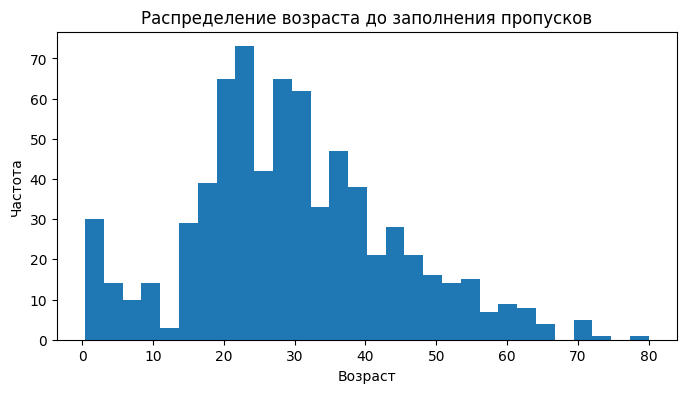

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(data['age'].dropna(), bins=30)
plt.title('Распределение возраста до заполнения пропусков')
plt.xlabel('Возраст')
plt.ylabel('Частота')
plt.show()

In [10]:
data_num_imputed = data.copy()

num_imputer = SimpleImputer(strategy='median')
data_num_imputed[['age']] = num_imputer.fit_transform(data_num_imputed[['age']])

print("Пропуски в age после заполнения:", data_num_imputed['age'].isnull().sum())

Пропуски в age после заполнения: 0


In [11]:
data_num_imputed[['age']].head(10)

,age
0,22.0
1,38.0
2,26.0
3,35.0
4,35.0
5,28.0
6,54.0
7,2.0
8,27.0
9,14.0


## 7. Обработка пропусков в категориальных признаках

In [12]:
print("Уникальные значения embarked:")
print(data['embarked'].unique())

print("\nУникальные значения deck:")
print(data['deck'].unique())

Уникальные значения embarked:
['S' 'C' 'Q' nan]

Уникальные значения deck:
[NaN, 'C', 'E', 'G', 'D', 'A', 'B', 'F']
Categories (7, object): ['A', 'B', 'C', 'D', 'E', 'F', 'G']


In [13]:
data_imputed = data_num_imputed.copy()

cat_imputer_freq = SimpleImputer(strategy='most_frequent')
data_imputed[['embarked']] = cat_imputer_freq.fit_transform(data_imputed[['embarked']])

cat_imputer_const = SimpleImputer(strategy='constant', fill_value='Unknown')
data_imputed[['deck']] = cat_imputer_const.fit_transform(data_imputed[['deck']])

print("Пропуски в embarked после заполнения:", data_imputed['embarked'].isnull().sum())
print("Пропуски в deck после заполнения:", data_imputed['deck'].isnull().sum())

Пропуски в embarked после заполнения: 0
Пропуски в deck после заполнения: 0


In [14]:
data_imputed[['embark_town']] = cat_imputer_freq.fit_transform(data_imputed[['embark_town']])
print("Пропуски в embark_town после заполнения:", data_imputed['embark_town'].isnull().sum())

Пропуски в embark_town после заполнения: 0


## 8. Проверка, что пропуски обработаны

In [16]:
missing_count_after = data_imputed.isnull().sum()
missing_percent_after = (data_imputed.isnull().sum() / len(data_imputed) * 100).round(2)

missing_table_after = pd.DataFrame({
    'Количество пропусков': missing_count_after,
    'Процент пропусков': missing_percent_after
})

missing_table_after[missing_table_after['Количество пропусков'] > 0]

,Количество пропусков,Процент пропусков


In [17]:
data_full = data.copy()

# числовые
num_cols_with_nan = data_full.select_dtypes(include=['int64', 'float64']).columns[data_full.select_dtypes(include=['int64', 'float64']).isnull().any()].tolist()
if num_cols_with_nan:
    num_imputer = SimpleImputer(strategy='median')
    data_full[num_cols_with_nan] = num_imputer.fit_transform(data_full[num_cols_with_nan])

# категориальные
cat_cols_with_nan = data_full.select_dtypes(include=['object', 'category', 'bool']).columns[data_full.select_dtypes(include=['object', 'category', 'bool']).isnull().any()].tolist()
for col in cat_cols_with_nan:
    if col == 'deck':
        imp = SimpleImputer(strategy='constant', fill_value='Unknown')
    else:
        imp = SimpleImputer(strategy='most_frequent')
    data_full[[col]] = imp.fit_transform(data_full[[col]])

print(data_full.isnull().sum()[data_full.isnull().sum() > 0])

Series([], dtype: int64)


## 9. Кодирование категориальных признаков

### 9.1. Label Encoding

In [18]:
data_encoded = data_imputed.copy()

le = LabelEncoder()
data_encoded['sex_label'] = le.fit_transform(data_encoded['sex'])

print("Категории признака sex:")
print(le.classes_)

data_encoded[['sex', 'sex_label']].head(10)

Категории признака sex:
['female' 'male']


,sex,sex_label
0,male,1
1,female,0
2,female,0
3,female,0
4,male,1
5,male,1
6,male,1
7,male,1
8,female,0
9,female,0


### 9.2. One-Hot Encoding

In [19]:
embarked_ohe = pd.get_dummies(data_encoded['embarked'], prefix='embarked')
embarked_ohe.head()

,embarked_C,embarked_Q,embarked_S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True


In [20]:
data_encoded = pd.concat([data_encoded, embarked_ohe], axis=1)
data_encoded.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_label,embarked_C,embarked_Q,embarked_S
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False,1,False,False,True
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0,True,False,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True,0,False,False,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0,False,False,True
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True,1,False,False,True


### 9.3. OneHotEncoder из sklearn

In [21]:
ohe = OneHotEncoder(sparse_output=False)
embarked_encoded = ohe.fit_transform(data_imputed[['embarked']])

embarked_encoded_df = pd.DataFrame(
    embarked_encoded,
    columns=ohe.get_feature_names_out(['embarked'])
)

embarked_encoded_df.head()

,embarked_C,embarked_Q,embarked_S
0,0.0,0.0,1.0
1,1.0,0.0,0.0
2,0.0,0.0,1.0
3,0.0,0.0,1.0
4,0.0,0.0,1.0


## 10. Масштабирование числовых признаков

In [22]:
data_encoded[['age', 'fare']].describe()

,age,fare
count,891.000000,891.000000
mean,29.361582,32.204208
std,13.019697,49.693429
min,0.420000,0.000000
25%,22.000000,7.910400
50%,28.000000,14.454200
75%,35.000000,31.000000
max,80.000000,512.329200


### 10.1. MinMaxScaler

In [23]:
data_scaled = data_encoded.copy()

minmax_scaler = MinMaxScaler()
data_scaled[['age_minmax', 'fare_minmax']] = minmax_scaler.fit_transform(data_scaled[['age', 'fare']])

data_scaled[['age', 'age_minmax', 'fare', 'fare_minmax']].head(10)

,age,age_minmax,fare,fare_minmax
0,22.0,0.271174,7.2500,0.014151
1,38.0,0.472229,71.2833,0.139136
2,26.0,0.321438,7.9250,0.015469
3,35.0,0.434531,53.1000,0.103644
4,35.0,0.434531,8.0500,0.015713
5,28.0,0.346569,8.4583,0.016510
6,54.0,0.673285,51.8625,0.101229
7,2.0,0.019854,21.0750,0.041136
8,27.0,0.334004,11.1333,0.021731
9,14.0,0.170646,30.0708,0.058694


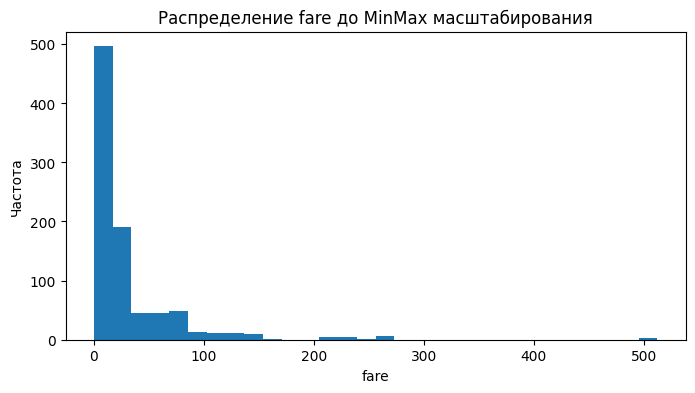

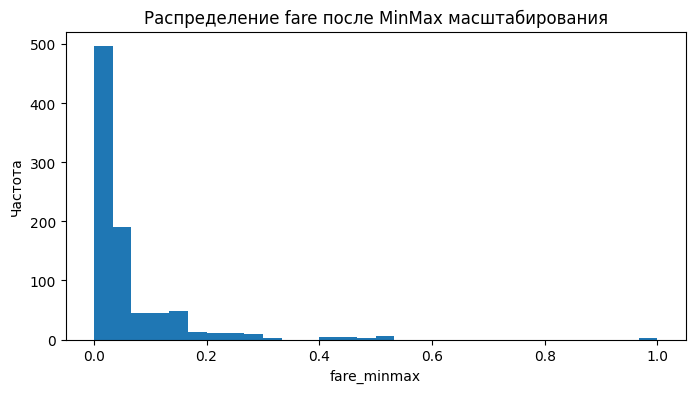

In [24]:
plt.figure(figsize=(8, 4))
plt.hist(data_scaled['fare'], bins=30)
plt.title('Распределение fare до MinMax масштабирования')
plt.xlabel('fare')
plt.ylabel('Частота')
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(data_scaled['fare_minmax'], bins=30)
plt.title('Распределение fare после MinMax масштабирования')
plt.xlabel('fare_minmax')
plt.ylabel('Частота')
plt.show()

### 10.2. StandardScaler

In [25]:
standard_scaler = StandardScaler()
data_scaled[['age_std', 'fare_std']] = standard_scaler.fit_transform(data_scaled[['age', 'fare']])

data_scaled[['age', 'age_std', 'fare', 'fare_std']].head(10)

,age,age_std,fare,fare_std
0,22.0,-0.565736,7.2500,-0.502445
1,38.0,0.663861,71.2833,0.786845
2,26.0,-0.258337,7.9250,-0.488854
3,35.0,0.433312,53.1000,0.420730
4,35.0,0.433312,8.0500,-0.486337
5,28.0,-0.104637,8.4583,-0.478116
6,54.0,1.893459,51.8625,0.395814
7,2.0,-2.102733,21.0750,-0.224083
8,27.0,-0.181487,11.1333,-0.424256
9,14.0,-1.180535,30.0708,-0.042956


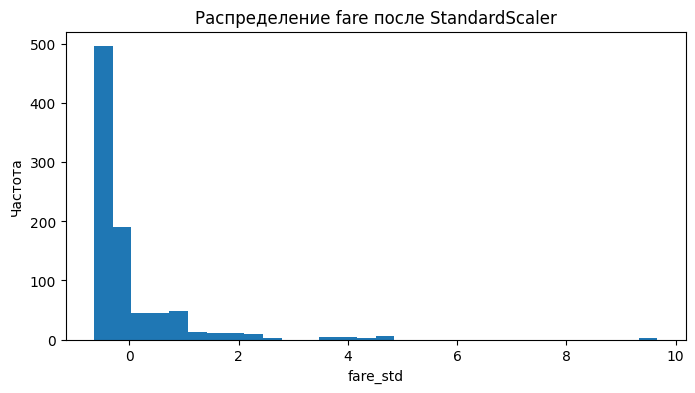

In [26]:
plt.figure(figsize=(8, 4))
plt.hist(data_scaled['fare_std'], bins=30)
plt.title('Распределение fare после StandardScaler')
plt.xlabel('fare_std')
plt.ylabel('Частота')
plt.show()

## 11. Итоговая проверка результата

In [27]:
print("Размер итогового датасета:", data_scaled.shape)
print("\nОставшиеся пропуски:")
print(data_scaled.isnull().sum()[data_scaled.isnull().sum() > 0])

data_scaled.head()

Размер итогового датасета: (891, 23)

Оставшиеся пропуски:
Series([], dtype: int64)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,sex_label,embarked_C,embarked_Q,embarked_S,age_minmax,fare_minmax,age_std,fare_std
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False,1,False,False,True,0.271174,0.014151,-0.565736,-0.502445
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,0,True,False,False,0.472229,0.139136,0.663861,0.786845
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True,0,False,False,True,0.321438,0.015469,-0.258337,-0.488854
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,0,False,False,True,0.434531,0.103644,0.433312,0.420730
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True,1,False,False,True,0.434531,0.015713,0.433312,-0.486337


# Вывод

В ходе лабораторной работы были изучены и применены основные методы предварительной обработки данных.
Сначала был выбран датасет Titanic, содержащий как категориальные признаки, так и пропущенные значения.
Далее был выполнен анализ структуры данных и выявлены признаки с пропусками.
Для числовых признаков пропуски были обработаны методом импьютации медианой, а для категориальных — наиболее частым значением и константой.
После этого были рассмотрены методы кодирования категориальных признаков: LabelEncoder и one-hot кодирование.
На заключительном этапе выполнено масштабирование числовых признаков с помощью MinMaxScaler и StandardScaler.
В результате были получены подготовленные данные, пригодные для дальнейшего использования при построении моделей машинного обучения.